# Post-process trip data

## Install and import packages

In [1]:
#!pip install --upgrade seaborn
!pip install plotly

  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import os

## Utils

In [83]:
# Set SAVE equals to True, in order to Save cleaned trip data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin1/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [47]:
##### Load trip data
#######trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 1200
#trip_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
#trip_data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
trip_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin1/Generated_data/epoch_{number}/EV_generated_data_{number}.csv')

# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11630 entries, 0 to 11629
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             11630 non-null  int64  
 1   charge_mode       11630 non-null  int64  
 2   duration_minutes  11630 non-null  float64
 3   km_driven         11630 non-null  float64
 4   charge            11630 non-null  float64
 5   id                11630 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 545.3 KB


In [48]:
trip_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,0,0,103.659843,10.490964,0.735457,0
1,0,0,105.239692,33.626091,-8.643642,1
2,0,0,141.457991,84.330054,-18.088922,2
3,0,0,58.533635,6.709347,-0.056010,3
4,0,0,57.666829,8.600618,-1.065171,4
5,0,0,54.146740,7.244678,-0.433559,5
6,0,0,50.261470,5.445782,0.324070,6
7,0,0,52.194976,5.589365,0.334247,7
8,0,0,57.468120,5.578205,0.736297,8
9,0,0,94.905084,8.068287,-0.054346,9


### Data description

In [49]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [50]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    print("\n🔍 Records with missing values:\n")
    print(records_with_nan.head(length))

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|


In [51]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,11630.0,25.233058,30.090679,2.491072,6.142045,8.964796,34.725691,189.484435
delta_soc,11630.0,-5.020432,7.809460,-47.696074,-9.857558,-1.019531,0.279196,13.194461


In [52]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

📊 Statistics on driven km:
 count    11630.000000
mean        25.233058
std         30.090679
min          2.491072
25%          6.142045
50%          8.964796
75%         34.725691
max        189.484435
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    11630.000000
mean         5.020432
std          7.809460
min        -13.194461
25%         -0.279196
50%          1.019531
75%          9.857558
max         47.696074
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    11630.000000
mean        12.683587
std         10.653097
min          0.797168
25%          5.761301
50%          7.393267
75%         17.817795
max         55.871233
Name: avg_speed, dtype: float64
99th percentile of average speed: 42.03 km/h

🛢️ Statistics on km per percentage of battery:
 count     11630.000000
mean        -17.218406
std        2133.237776
min     -197088.026486
25%          -5.271178
50%           3.827550
75%           5.029

### Identify and remove anomalous records

In [53]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of snapshot records: 0


In [54]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [55]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of records with negative duration: 0


In [56]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [57]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
if length > 0:
    stationary_records.head(length)

Number of stationary records: 0


In [58]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [59]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 1088


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
29,0,0,222.095602,5.052939,4.515485,30,4.515485,-4.515485,1.365071,-1.119025,-0.893635
36,0,0,134.538676,3.585328,3.817180,38,3.817180,-3.817180,1.598943,-0.939261,-1.064667
41,0,0,83.406529,3.927835,1.291123,43,1.291123,-1.291123,2.825559,-3.042185,-0.328711
47,0,0,125.788690,3.473837,1.431681,52,1.431681,-1.431681,1.656987,-2.426404,-0.412133
48,0,0,55.889783,6.061632,1.185074,54,1.185074,-1.185074,6.507413,-5.114981,-0.195504
...,...,...,...,...,...,...,...,...,...,...,...
11588,0,0,96.029950,4.084555,3.589864,13552,3.589864,-3.589864,2.552050,-1.137802,-0.878887
11596,0,0,135.340940,3.286179,1.777088,13561,1.777088,-1.777088,1.456845,-1.849193,-0.540776
11598,0,0,116.639040,2.756114,1.239916,13563,1.239916,-1.239916,1.417766,-2.222823,-0.449878
11604,0,0,179.288719,5.072778,2.451056,13569,2.451056,-2.451056,1.697634,-2.069629,-0.483178


In [60]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [61]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
if length > 0:
    anomalous_movement_records.head(length)

Number of anomalous movement records: 0


In [62]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [63]:
# Identify records with high average speed 
#######################
SPEED_THRESHOLD = 130 #
#######################

anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]

length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [64]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [65]:
# Identify anomalous records with high discharge per km
############################
MAX_DISCHARGE_PER_KM = 0.9 #
############################

anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

anomalous_discharge_records.head(length)

Number of anomalous discharge records: 3


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
266,0,0,91.485913,4.436340,-4.857193,337,-4.857193,4.857193,2.909524,0.913355,1.094865
3464,0,0,95.640885,3.018641,-2.897281,4444,-2.897281,2.897281,1.893735,1.041888,0.959796
3489,0,0,89.978405,3.601198,-3.858579,4474,-3.858579,3.858579,2.401375,0.933296,1.071471


In [66]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [67]:
# Identify anomalous records with low discharge per km
############################
MIN_DISCHARGE_PER_KM = -1
##########################################################



anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [68]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [69]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 905


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
5836,0,0,110.735039,9.112972,-0.000100,7519,-0.000100,0.000100,4.937718,90702.196677,0.000011
3360,0,0,56.310130,6.895886,-0.000819,4312,-0.000819,0.000819,7.347757,8418.972538,0.000119
10145,0,0,58.592487,7.814242,-0.001163,13084,-0.001163,0.001163,8.001957,6721.665037,0.000149
7492,0,0,117.281318,9.303704,-0.002151,9679,-0.002151,0.002151,4.759686,4326.006969,0.000231
292,0,0,108.307286,9.584759,-0.002457,370,-0.002457,0.002457,5.309759,3900.820237,0.000256
...,...,...,...,...,...,...,...,...,...,...,...
186,0,0,63.160544,5.966294,-0.297386,237,-0.297386,0.297386,5.667741,20.062446,0.049844
6516,0,0,107.871245,10.752478,-0.536004,8399,-0.536004,0.536004,5.980729,20.060439,0.049849
4036,0,0,112.907130,11.864111,-0.591692,5180,-0.591692,0.591692,6.304710,20.051170,0.049872
3303,0,0,62.817368,6.177917,-0.308519,4244,-0.308519,0.308519,5.900836,20.024399,0.049939


In [70]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [71]:
# Identify anomalous records with low km per percentage of battery discharge 
############################
MIN_KM_PER_DISCHARGE = -10 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 2047


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
4992,0,0,52.863288,6.029716,0.602201,7033,0.602201,-0.602201,6.843746,-10.012790,-0.099872
8342,0,0,64.852258,6.879979,0.686137,11752,0.686137,-0.686137,6.365218,-10.027123,-0.099730
9514,0,0,56.765516,5.394608,0.537885,13422,0.537885,-0.537885,5.701992,-10.029295,-0.099708
4631,0,0,59.294852,6.099931,0.608125,6498,0.608125,-0.608125,6.172473,-10.030726,-0.099694
1544,0,0,86.282991,6.597995,0.657519,2201,0.657519,-0.657519,4.588154,-10.034682,-0.099654
...,...,...,...,...,...,...,...,...,...,...,...
7411,0,0,53.207377,5.750811,0.001384,10452,0.001384,-0.001384,6.484977,-4154.252156,-0.000241
2120,0,0,52.986919,6.203665,0.001215,3012,0.001215,-0.001215,7.024751,-5104.920052,-0.000196
4464,0,0,55.969901,5.077563,0.000232,6265,0.000232,-0.000232,5.443172,-21846.722080,-0.000046
7647,0,0,136.294155,7.832600,0.000111,10779,0.000111,-0.000111,3.448101,-70636.052906,-0.000014


In [72]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [73]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7587 entries, 0 to 7586
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   7587 non-null   int64  
 1   charge_mode             7587 non-null   int64  
 2   duration_minutes        7587 non-null   float64
 3   km_driven               7587 non-null   float64
 4   charge                  7587 non-null   float64
 5   id                      7587 non-null   int64  
 6   delta_soc               7587 non-null   float64
 7   discharge               7587 non-null   float64
 8   avg_speed               7587 non-null   float64
 9   km_per_perc_of_battery  7587 non-null   float64
 10  discharge_per_km        7587 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 652.1 KB


In [74]:
# Print statistics
print('Statistics after post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

📊 Statistics on driven km:
 count    7587.000000
mean       35.266734
std        33.109801
min         2.560657
25%         8.504629
50%        19.354822
75%        59.527892
max       189.484435
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    7587.000000
mean        8.135027
std         8.022260
min        -0.999840
25%         1.138158
50%         5.536810
75%        14.513407
max        47.696074
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    7587.000000
mean       16.584279
std        11.334343
min         1.372450
25%         7.071130
50%        12.174463
75%        25.020882
max        55.871233
Name: avg_speed, dtype: float64
99th percentile of average speed: 43.39 km/h

🛢️ Statistics on km per percentage of battery:
 count    7587.000000
mean        4.218840
std         5.141863
min        -9.996776
25%         3.486678
50%         4.232902
75%         5.174279
max        19.949439
Name: km_per_p

## Data Visualization and Comparative Analysis

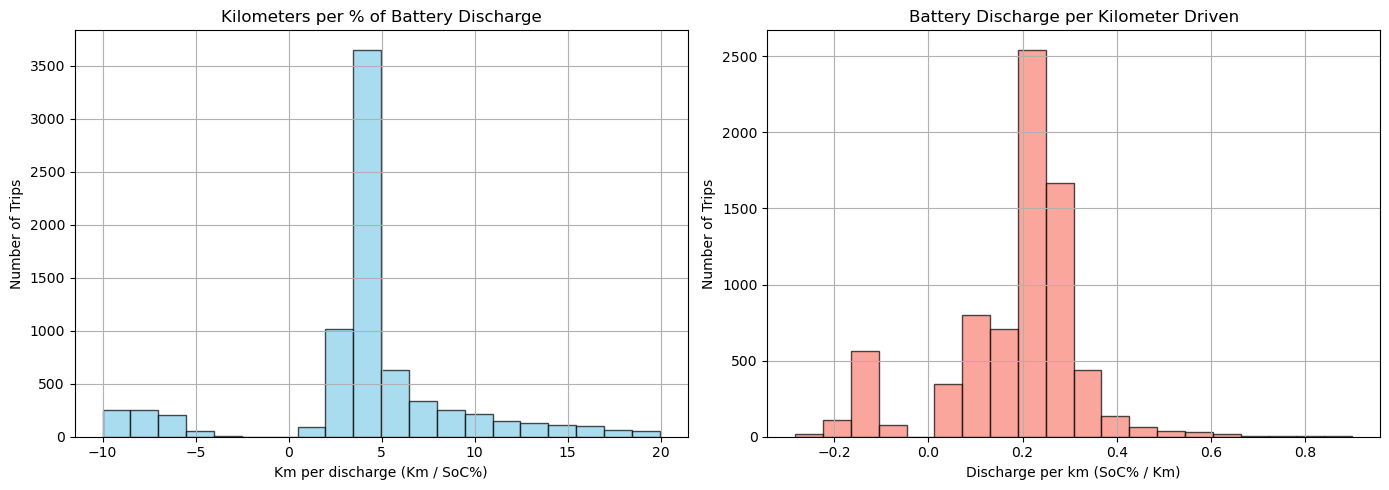

In [75]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [76]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,105.239692,33.626091,-8.643642,1,-8.643642,8.643642,19.171146,3.890269,0.257052
1,0,0,141.457991,84.330054,-18.088922,2,-18.088922,18.088922,35.768946,4.661972,0.214501
2,0,0,57.666829,8.600618,-1.065171,4,-1.065171,1.065171,8.948594,8.074403,0.123848
3,0,0,54.146740,7.244678,-0.433559,5,-0.433559,0.433559,8.027828,16.709791,0.059845
4,0,0,57.468120,5.578205,0.736297,8,0.736297,-0.736297,5.823965,-7.576021,-0.131995


In [77]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Record with maximum Km/SoC driven:\n")
max_km_row.head()


 Record with maximum Km/SoC driven:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
7121,0,0,53.968769,6.777669,-0.339742,12746,-0.339742,0.339742,7.535101,19.949439,0.050127


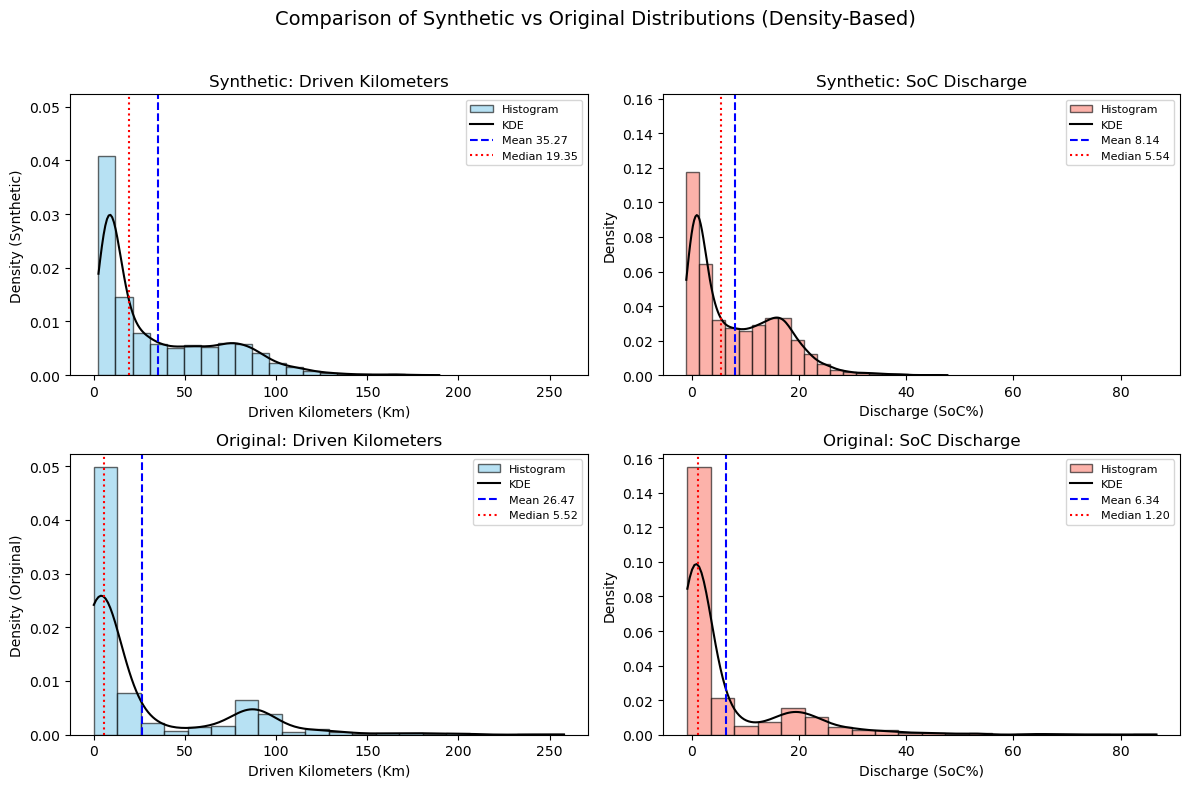

In [78]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    """Plots histogram + KDE + mean & median, using DENSITY (not frequency)."""
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(
        y, bins=bins, density=density, alpha=0.6,
        color=color, edgecolor='black', label='Histogram'
    )

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'Mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'Median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)


# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Discharge', xlabel='Discharge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(trip_data_original.get('km_driven', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data_original.get('discharge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Discharge', xlabel='Discharge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


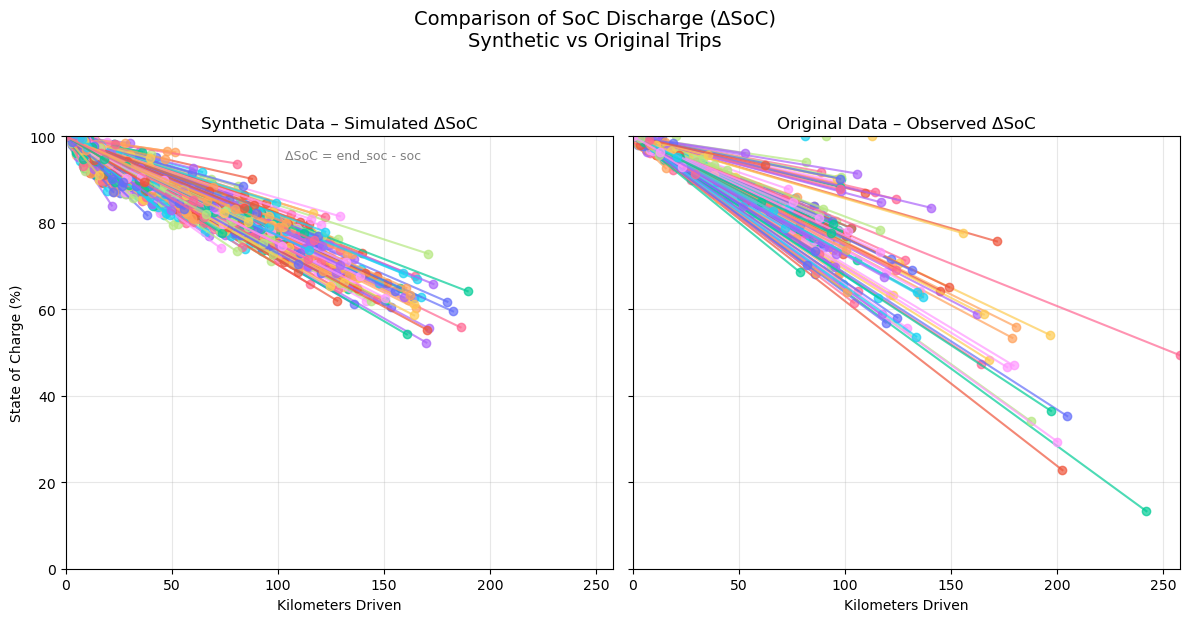

In [79]:
# --- Synthetic data prep ---
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge']

# --- Shared scales ---
max_km_driven = max(trip_data['km_driven'].max(), trip_data_original['km_driven'].max())

# --- Colors ---
colors = px.colors.qualitative.Plotly

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ====================================================
# LEFT PANEL – SYNTHETIC
# ====================================================
ax = axes[0]
for i, (_, row) in enumerate(trip_data.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Synthetic Data – Simulated ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.text(max_km_driven * 0.4, 95, "ΔSoC = end_soc - soc", fontsize=9, color='gray')

# ====================================================
# RIGHT PANEL – ORIGINAL
# ====================================================
ax = axes[1]
for i, (_, row) in enumerate(trip_data_original.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Original Data – Observed ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# ====================================================
# SHARED SETTINGS
# ====================================================
# Reverse y-axis for intuitive "battery discharge" visualization
for ax in axes:
    ax.invert_yaxis()

fig.suptitle('Comparison of SoC Discharge (ΔSoC)\nSynthetic vs Original Trips', fontsize=14, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [80]:
trip_data['discharge_per_km'].describe()

count    7587.000000
mean        0.188495
std         0.141234
min        -0.282578
25%         0.128951
50%         0.221612
75%         0.261484
max         0.899271
Name: discharge_per_km, dtype: float64

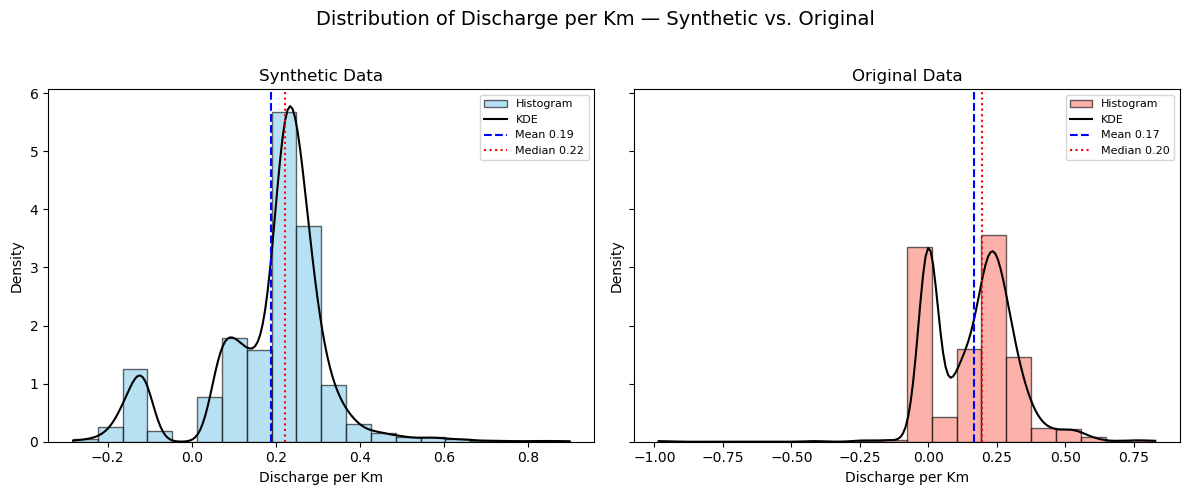

In [81]:
# --- Distribution of Discharge per Km ---
# --- Create side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left panel — synthetic data
plot_hist_with_kde(
    trip_data.get('discharge_per_km', pd.Series(dtype=float)),
    axes[0],
    color='skyblue',
    title='Synthetic Data',
    xlabel='Discharge per Km'
)

# Right panel — original data
plot_hist_with_kde(
    trip_data_original.get('discharge_per_km', pd.Series(dtype=float)),
    axes[1],
    color='salmon',
    title='Original Data',
    xlabel='Discharge per Km',
    density=True
)

# --- Styling ---
fig.suptitle('Distribution of Discharge per Km — Synthetic vs. Original', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Original dataset

In [36]:
#trip_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
trip_data_original = pd.read_csv('./datasets/EV_data.csv')

trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145 entries, 0 to 1144
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1145 non-null   float64
 1   timestamp    1145 non-null   object 
 2   end_time     1145 non-null   object 
 3   odo          1145 non-null   float64
 4   end_odo      1145 non-null   float64
 5   soc          1145 non-null   float64
 6   end_soc      1145 non-null   float64
 7   event        1145 non-null   object 
 8   charge_mode  1145 non-null   object 
dtypes: float64(5), object(4)
memory usage: 80.6+ KB


In [37]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1145
📊 Statistics on driven km:
 count    1145.000000
mean       25.680523
std        40.549802
min         0.000000
25%         1.332590
50%         5.328130
75%        25.343750
max       257.906250
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    1145.000000
mean        6.240437
std        10.845429
min        -0.800000
25%         0.000000
50%         1.200000
75%         5.900000
max        86.700000
Name: discharge, dtype: float64


In [38]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [39]:
MAX_DISCHARGE_PER_KM = 0.9
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 35


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
52,-8.996320e+18,2021-01-11 14:12:00,2021-01-11 14:18:00,5540.781250,5540.812500,74.5,74.1,trip,0,0.031250,0.4,0.078125,12.800000
68,-8.996320e+18,2021-01-14 10:47:00,2021-01-14 10:52:00,6163.546875,6163.593750,85.8,85.4,trip,0,0.046875,0.4,0.117188,8.533333
92,-8.996320e+18,2021-01-17 14:20:00,2021-01-17 15:14:00,6563.365008,6569.703125,92.5,73.7,trip,0,6.338117,18.8,0.337134,2.966181
96,-8.996320e+18,2021-01-17 20:26:00,2021-01-17 20:34:00,6589.171875,6589.281250,67.8,67.4,trip,0,0.109375,0.4,0.273438,3.657143
100,-8.996320e+18,2021-01-19 09:46:00,2021-01-19 10:59:00,6766.881646,6774.593750,78.0,60.3,trip,0,7.712104,17.7,0.435712,2.295094
129,-8.996320e+18,2021-01-24 14:29:00,2021-01-24 15:23:00,7619.759321,7631.140625,78.8,59.2,trip,0,11.381304,19.6,0.580679,1.722123
165,-8.996320e+18,2021-02-02 17:09:00,2021-02-02 17:13:00,8665.969882,8666.078125,100.0,99.6,trip,0,0.108243,0.4,0.270608,3.695389
174,-8.996320e+18,2021-02-04 10:54:00,2021-02-04 13:26:00,8932.078125,8932.109375,49.0,48.2,trip,0,0.031250,0.8,0.039063,25.600000
190,-8.996320e+18,2021-02-07 15:15:00,2021-02-07 19:40:00,9326.046875,9327.125000,40.7,38.4,trip,0,1.078125,2.3,0.468750,2.133333
213,-8.996320e+18,2021-02-15 12:05:00,2021-02-15 13:08:00,10210.187500,10210.218750,83.1,82.7,trip,0,0.031250,0.4,0.078125,12.800000


In [40]:
MIN_DISCHARGE_PER_KM = -1
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 1


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
42,-8.996320e+18,2021-01-08 11:13:00,2021-01-08 13:23:00,5201.6875,5201.765625,40.0,40.3,trip,0,0.078125,-0.3,-0.260417,-3.84


In [41]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))



Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [42]:
# Identify anomalous records with low km per percentage of battery discharge 
############################
MIN_KM_PER_DISCHARGE = -10 #
############################

anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [43]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1109 non-null   float64
 1   timestamp               1109 non-null   object 
 2   end_time                1109 non-null   object 
 3   odo                     1109 non-null   float64
 4   end_odo                 1109 non-null   float64
 5   soc                     1109 non-null   float64
 6   end_soc                 1109 non-null   float64
 7   event                   1109 non-null   object 
 8   charge_mode             1109 non-null   object 
 9   km_driven               1109 non-null   float64
 10  discharge               1109 non-null   float64
 11  km_per_perc_of_battery  1109 non-null   float64
 12  discharge_per_km        1109 non-null   float64
dtypes: float64(9), object(4)
memory usage: 112.8+ KB


In [44]:
trip_data_original['discharge_per_km'].describe()

count    1109.000000
mean        0.167521
std         0.148489
min        -0.984615
25%         0.000000
50%         0.196420
75%         0.261642
max         0.827209
Name: discharge_per_km, dtype: float64

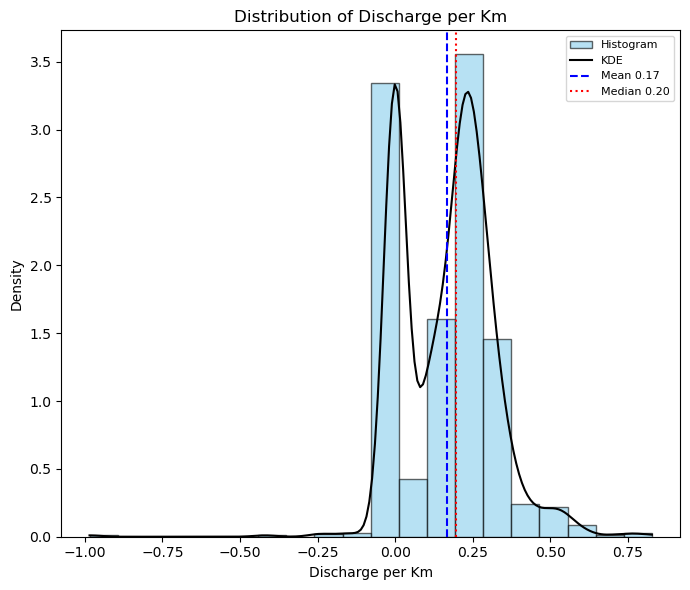

In [45]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

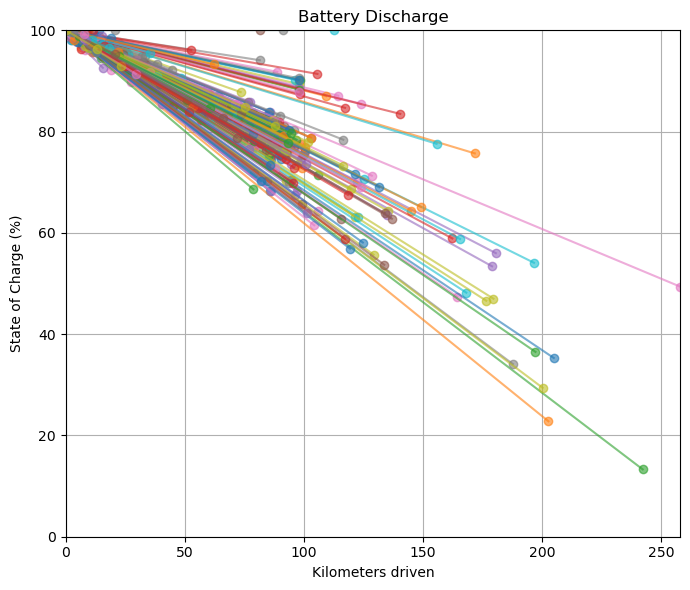

In [46]:
#######################################################
#visualiza delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Save trip data cleaned

In [84]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_path_csv, index=False)

In [85]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,105.239692,33.626091,-8.643642,1,-8.643642,8.643642,19.171146,3.890269,0.257052,100,91.356358
1,0,0,141.457991,84.330054,-18.088922,2,-18.088922,18.088922,35.768946,4.661972,0.214501,100,81.911078
2,0,0,57.666829,8.600618,-1.065171,4,-1.065171,1.065171,8.948594,8.074403,0.123848,100,98.934829
3,0,0,54.146740,7.244678,-0.433559,5,-0.433559,0.433559,8.027828,16.709791,0.059845,100,99.566441
4,0,0,57.468120,5.578205,0.736297,8,0.736297,-0.736297,5.823965,-7.576021,-0.131995,100,100.736297


In [86]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7587 entries, 0 to 7586
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   7587 non-null   int64  
 1   charge_mode             7587 non-null   int64  
 2   duration_minutes        7587 non-null   float64
 3   km_driven               7587 non-null   float64
 4   charge                  7587 non-null   float64
 5   id                      7587 non-null   int64  
 6   delta_soc               7587 non-null   float64
 7   discharge               7587 non-null   float64
 8   avg_speed               7587 non-null   float64
 9   km_per_perc_of_battery  7587 non-null   float64
 10  discharge_per_km        7587 non-null   float64
 11  soc                     7587 non-null   int64  
 12  end_soc                 7587 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 770.7 KB
